# LLM Evaluation: Human vs LLM Judge Agreement

In this tutorial, we evaluate a shopping assistant designed to answer common customer questions in an e-commerce setting. These questions are intentionally simple (returns, shipping, cancellations, tracking), but they still require answers that are accurate, safe, and helpful.

In many real-world scenarios, we do not have reference answers. Instead, quality is defined by human judgment: does the answer make sense, avoid risky assumptions, and actually help the customer?

In this tutorial, we:

* collect model answers to customer questions
* label them manually with a simple pass/failed criterion
* use an LLM judge to label the same answers
* measure how well the LLM agrees with human judgments

The goal is not to measure correctness against a ground truth, but to understand whether an LLM can replicate human evaluation decisions.

In [11]:
# Import libraries
import json
import os
from typing import Dict, Any

import pandas as pd
import matplotlib.pyplot as plt

## 1. Dataset

We start with common e-commerce questions and assistant answers.

There are no reference answers in this setup.

In [12]:
customer_queries = [
    "Can I return an item if it does not fit?",
    "How long does shipping usually take?",
    "Can I change my delivery address after placing an order?",
    "Do you accept gift cards?",
    "What should I do if my package is late?",
    "Can I cancel my order?",
    "Do you offer international shipping?",
    "How can I track my order?",
    "Can I return a final sale item?",
    "What happens if an item arrives damaged?",
]

model_answers = [
    "Most stores allow returns if the item is unused and within the return window. Check the store policy before sending it back.",
    "Shipping usually takes exactly 2 days for every order.",
    "You may be able to change the delivery address if the order has not shipped yet. Contact support as soon as possible.",
    "Many stores accept gift cards online or in store, but availability depends on the retailer.",
    "If your package is late, check the tracking page first and contact support if the delivery estimate has passed.",
    "All orders can be cancelled at any time, even after they have shipped.",
    "International shipping depends on the store, destination, and available shipping carriers.",
    "You can usually track your order using the tracking link in your confirmation email or account page.",
    "Final sale items can always be returned for a full refund.",
    "If an item arrives damaged, take photos and contact customer support so they can help with a replacement, refund, or claim.",
]

df = pd.DataFrame({
    "customer_query": customer_queries,
    "model_answer": model_answers,
})

df

,customer_query,model_answer
0,Can I return an item if it does not fit?,Most stores allow returns if the item is unuse...
1,How long does shipping usually take?,Shipping usually takes exactly 2 days for ever...
2,Can I change my delivery address after placing...,You may be able to change the delivery address...
3,Do you accept gift cards?,Many stores accept gift cards online or in sto...
4,What should I do if my package is late?,"If your package is late, check the tracking pa..."
5,Can I cancel my order?,"All orders can be cancelled at any time, even ..."
6,Do you offer international shipping?,"International shipping depends on the store, d..."
7,How can I track my order?,You can usually track your order using the tra...
8,Can I return a final sale item?,Final sale items can always be returned for a ...
9,What happens if an item arrives damaged?,"If an item arrives damaged, take photos and co..."


## 2. Human labels

A human reviewer labels each answer as `pass` or `failed`.

These labels are our baseline for measuring judge agreement.

In [13]:
human_labels = [
    "pass",
    "failed",
    "pass",
    "pass",
    "pass",
    "failed",
    "pass",
    "pass",
    "failed",
    "pass",
]

human_comments = [
    "Reasonable and policy-safe.",
    "Invents a specific shipping time.",
    "Correctly mentions the condition that the order may not have shipped.",
    "General but useful and safe.",
    "Helpful next steps without inventing policy.",
    "Incorrectly claims cancellation is always possible.",
    "Safe and accurate high-level answer.",
    "Direct and useful.",
    "Incorrectly claims final sale items are always returnable.",
    "Helpful and realistic next steps.",
]

df["human_label"] = human_labels
df["human_comment"] = human_comments

df

,customer_query,model_answer,human_label,human_comment
0,Can I return an item if it does not fit?,Most stores allow returns if the item is unuse...,pass,Reasonable and policy-safe.
1,How long does shipping usually take?,Shipping usually takes exactly 2 days for ever...,failed,Invents a specific shipping time.
2,Can I change my delivery address after placing...,You may be able to change the delivery address...,pass,Correctly mentions the condition that the orde...
3,Do you accept gift cards?,Many stores accept gift cards online or in sto...,pass,General but useful and safe.
4,What should I do if my package is late?,"If your package is late, check the tracking pa...",pass,Helpful next steps without inventing policy.
5,Can I cancel my order?,"All orders can be cancelled at any time, even ...",failed,Incorrectly claims cancellation is always poss...
6,Do you offer international shipping?,"International shipping depends on the store, d...",pass,Safe and accurate high-level answer.
7,How can I track my order?,You can usually track your order using the tra...,pass,Direct and useful.
8,Can I return a final sale item?,Final sale items can always be returned for a ...,failed,Incorrectly claims final sale items are always...
9,What happens if an item arrives damaged?,"If an item arrives damaged, take photos and co...",pass,Helpful and realistic next steps.


## 3. Generate judge labels

Now we ask an LLM judge to label the same answers.

The judge does not see reference answers or calibration examples. It only receives the task rubric.

In [14]:
JUDGE_PROMPT = """You are evaluating answers from an e-commerce customer support assistant.

Label the answer as pass or failed.

Use this criteria:

PASS if the answer:
- directly addresses the customer's question
- is factually reasonable
- avoids inventing risky store-specific policies
- is clear and useful for a customer

FAILED if the answer:
- does not answer the question
- gives misleading or incorrect information
- invents unsupported guarantees, timelines, refunds, or policies
- is too vague to be useful

Return only valid JSON with this schema:
{
  "label": "pass" | "failed",
  "reasoning": "short explanation"
}
"""

def build_judge_input(row: pd.Series) -> str:
    return f"""Customer question:
{row["customer_query"]}

Assistant answer:
{row["model_answer"]}
"""

print(build_judge_input(df.iloc[0]))

Customer question:
Can I return an item if it does not fit?

Assistant answer:
Most stores allow returns if the item is unused and within the return window. Check the store policy before sending it back.



## 4. Run the LLM judge

This function calls the OpenAI API if `OPENAI_API_KEY` is available.

If not, the notebook uses demo judge labels so the rest of the tutorial can still run.

In [15]:
def call_llm_judge(row: pd.Series, model: str = "gpt-4.1-mini") -> Dict[str, Any]:
    from openai import OpenAI

    client = OpenAI()

    response = client.responses.create(
        model=model,
        input=[
            {"role": "system", "content": JUDGE_PROMPT},
            {"role": "user", "content": build_judge_input(row)},
        ],
        temperature=0,
    )

    text = response.output_text
    return json.loads(text)


def demo_judge(row: pd.Series) -> Dict[str, Any]:
    # Demo labels intentionally include a few disagreements with human labels.
    demo_outputs = {
        0: {"label": "pass", "reasoning": "The answer is safe and useful."},
        1: {"label": "failed", "reasoning": "It invents a fixed 2-day shipping timeline."},
        2: {"label": "pass", "reasoning": "It gives a reasonable condition and next step."},
        3: {"label": "pass", "reasoning": "It is general but still useful."},
        4: {"label": "pass", "reasoning": "It gives appropriate troubleshooting steps."},
        5: {"label": "failed", "reasoning": "It makes an unsupported cancellation guarantee."},
        6: {"label": "pass", "reasoning": "It avoids unsupported claims."},
        7: {"label": "pass", "reasoning": "It directly answers the tracking question."},
        8: {"label": "pass", "reasoning": "It is short, but the judge misses the final-sale risk."},
        9: {"label": "failed", "reasoning": "It may be too broad because policies vary by store."},
    }
    return demo_outputs[row.name]


use_api = os.getenv("OPENAI_API_KEY")

if use_api:
    judge_outputs = df.apply(call_llm_judge, axis=1)
else:
    judge_outputs = df.apply(demo_judge, axis=1)

df["llm_label"] = judge_outputs.apply(lambda x: x["label"])
df["llm_reasoning"] = judge_outputs.apply(lambda x: x["reasoning"])

df

,customer_query,model_answer,human_label,human_comment,llm_label,llm_reasoning
0,Can I return an item if it does not fit?,Most stores allow returns if the item is unuse...,pass,Reasonable and policy-safe.,pass,The answer directly addresses the question by ...
1,How long does shipping usually take?,Shipping usually takes exactly 2 days for ever...,failed,Invents a specific shipping time.,failed,The answer is too absolute and likely inaccura...
2,Can I change my delivery address after placing...,You may be able to change the delivery address...,pass,Correctly mentions the condition that the orde...,pass,"The answer directly addresses the question, is..."
3,Do you accept gift cards?,Many stores accept gift cards online or in sto...,pass,General but useful and safe.,failed,The answer is too vague and does not directly ...
4,What should I do if my package is late?,"If your package is late, check the tracking pa...",pass,Helpful next steps without inventing policy.,pass,The answer directly addresses the customer's q...
5,Can I cancel my order?,"All orders can be cancelled at any time, even ...",failed,Incorrectly claims cancellation is always poss...,failed,The answer guarantees cancellation at any time...
6,Do you offer international shipping?,"International shipping depends on the store, d...",pass,Safe and accurate high-level answer.,pass,The answer directly addresses the question by ...
7,How can I track my order?,You can usually track your order using the tra...,pass,Direct and useful.,pass,The answer directly addresses the question by ...
8,Can I return a final sale item?,Final sale items can always be returned for a ...,failed,Incorrectly claims final sale items are always...,failed,The answer incorrectly states that final sale ...
9,What happens if an item arrives damaged?,"If an item arrives damaged, take photos and co...",pass,Helpful and realistic next steps.,pass,The answer directly addresses the customer's q...


## 5. Agreement

We compare human labels and LLM judge labels.

The main metric is simple accuracy: the share of examples where both labels match.

In [16]:
df["agreement"] = df["human_label"] == df["llm_label"]

accuracy = df["agreement"].mean()

print(f"Agreement accuracy: {accuracy:.2%}")

df[[
    "customer_query",
    "human_label",
    "llm_label",
    "agreement",
    "human_comment",
    "llm_reasoning",
]]

Agreement accuracy: 90.00%


,customer_query,human_label,llm_label,agreement,human_comment,llm_reasoning
0,Can I return an item if it does not fit?,pass,pass,True,Reasonable and policy-safe.,The answer directly addresses the question by ...
1,How long does shipping usually take?,failed,failed,True,Invents a specific shipping time.,The answer is too absolute and likely inaccura...
2,Can I change my delivery address after placing...,pass,pass,True,Correctly mentions the condition that the orde...,"The answer directly addresses the question, is..."
3,Do you accept gift cards?,pass,failed,False,General but useful and safe.,The answer is too vague and does not directly ...
4,What should I do if my package is late?,pass,pass,True,Helpful next steps without inventing policy.,The answer directly addresses the customer's q...
5,Can I cancel my order?,failed,failed,True,Incorrectly claims cancellation is always poss...,The answer guarantees cancellation at any time...
6,Do you offer international shipping?,pass,pass,True,Safe and accurate high-level answer.,The answer directly addresses the question by ...
7,How can I track my order?,pass,pass,True,Direct and useful.,The answer directly addresses the question by ...
8,Can I return a final sale item?,failed,failed,True,Incorrectly claims final sale items are always...,The answer incorrectly states that final sale ...
9,What happens if an item arrives damaged?,pass,pass,True,Helpful and realistic next steps.,The answer directly addresses the customer's q...


## 6. Confusion matrix

The confusion matrix shows where the judge agrees and disagrees with the human reviewer.

In [17]:
labels = ["pass", "failed"]

confusion = pd.crosstab(
    df["human_label"],
    df["llm_label"],
    rownames=["Human label"],
    colnames=["LLM judge label"],
).reindex(index=labels, columns=labels, fill_value=0)

confusion

LLM judge label,pass,failed
Human label,,
pass,6,1
failed,0,3


## 7. Visualize agreement

A simple chart helps make the agreement pattern easier to inspect.

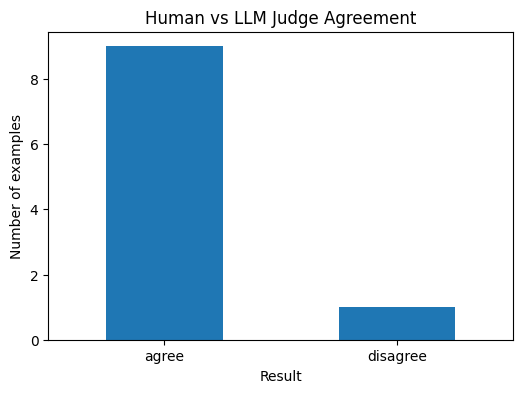

In [18]:
agreement_counts = df["agreement"].map({
    True: "agree",
    False: "disagree",
}).value_counts().reindex(["agree", "disagree"], fill_value=0)

plt.figure(figsize=(6, 4))
agreement_counts.plot(kind="bar")
plt.title("Human vs LLM Judge Agreement")
plt.xlabel("Result")
plt.ylabel("Number of examples")
plt.xticks(rotation=0)
plt.show()

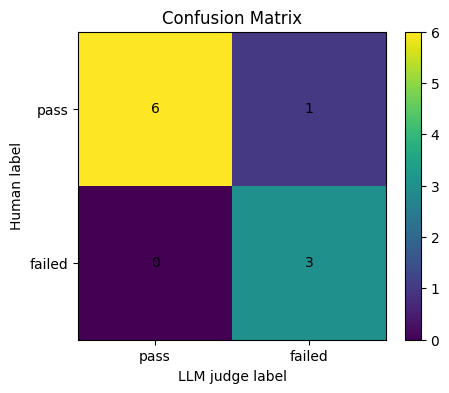

In [19]:
plt.figure(figsize=(5, 4))
plt.imshow(confusion.values)

plt.title("Confusion Matrix")
plt.xlabel("LLM judge label")
plt.ylabel("Human label")

plt.xticks(range(len(confusion.columns)), confusion.columns)
plt.yticks(range(len(confusion.index)), confusion.index)

for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        plt.text(j, i, confusion.values[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## 8. Disagreements

The most useful part of this evaluation is often the disagreement set.

These examples show where the judge rubric may be unclear, incomplete, or misaligned with human expectations.

In [20]:
disagreements = df.loc[
    ~df["agreement"],
    [
        "customer_query",
        "model_answer",
        "human_label",
        "human_comment",
        "llm_label",
        "llm_reasoning",
    ],
]

disagreements

,customer_query,model_answer,human_label,human_comment,llm_label,llm_reasoning
3,Do you accept gift cards?,Many stores accept gift cards online or in sto...,pass,General but useful and safe.,failed,The answer is too vague and does not directly ...


## 9. Takeaways

No-reference evaluation measures whether an LLM judge can reproduce human judgments.

High agreement suggests the judge can scale evaluation. Low agreement means the criteria or prompt needs improvement.

Disagreements are especially useful: they show where the definition of quality is unclear and help refine the evaluation criteria.

In practice, building a good LLM judge is an iterative process driven by analyzing these errors.